# Comparing MCMC algorithms with MCMCInference


In addition to the `NumPyro` inference methods, `dynestyx` provides the `MCMCInference` interface for advanced MCMC methods using NumPyro and BlackJAX.

The interface mirrors that of `Filter`: you pass in a config, which includes all relevant hyperparameters. This is passed to an `MCMCInference` object, which accepts

- the MCMC config dataclass (`NUTSConfig`, `HMCConfig`, `SGLDConfig`, `MALAConfig`)
- a model function with signature
  `model(obs_times, obs_values, ctrl_times=None, ctrl_values=None, ...)`

Then inference can be run using

```python
posterior_samples = inference.run(rng_key, obs_times, obs_values)
```

This works with the various different inference contexts, e.g., `Filter` or `DiscreteTimeSimulator`.

In [1]:
import time

import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"

import arviz as az
import dynestyx as dsx
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

from dynestyx.inference.filters import Filter, KFConfig
from dynestyx.inference.mcmc import MCMCInference
from dynestyx.inference.mcmc_configs import (
    HMCConfig,
    MALAConfig,
    NUTSConfig,
    SGLDConfig,
)
from dynestyx.models.lti_dynamics import LTI_discrete
from dynestyx.simulators import DiscreteTimeSimulator

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def discrete_time_lti_simplified_model(
    obs_times=None,
    obs_values=None,
    ctrl_times=None,
    ctrl_values=None,
):
    alpha = numpyro.sample("alpha", dist.Uniform(-0.7, 0.7))

    A = jnp.array([[alpha, 0.1], [0.1, 0.8]])
    Q = 0.1 * jnp.eye(2)
    H = jnp.array([[1.0, 0.0]])
    R = jnp.array([[0.5**2]])
    B = jnp.array([[0.1], [0.0]])
    D = jnp.array([[0.01]])

    dynamics = LTI_discrete(A=A, Q=Q, H=H, R=R, B=B, D=D)

    dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )


def make_data(seed=0):
    obs_times = jnp.arange(start=0.0, stop=30.0, step=0.05)
    true_params = {"alpha": jnp.array(0.35)}

    predictive = Predictive(
        discrete_time_lti_simplified_model,
        params=true_params,
        num_samples=1,
        exclude_deterministic=False,
    )

    with DiscreteTimeSimulator():
        synthetic = predictive(jr.PRNGKey(seed), obs_times=obs_times)

    obs_values = synthetic["observations"].squeeze(0)
    return obs_times, obs_values, true_params

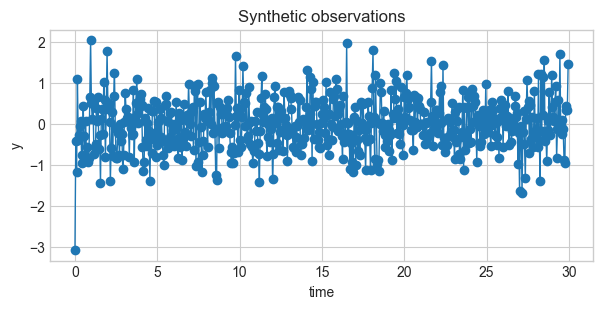

True alpha: 0.3499999940395355


In [3]:
obs_times, obs_values, true_params = make_data(seed=0)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.asarray(obs_times), np.asarray(obs_values).squeeze(-1), marker="o", lw=1)
ax.set_title("Synthetic observations")
ax.set_xlabel("time")
ax.set_ylabel("y")
plt.show()

print("True alpha:", float(true_params["alpha"]))

## Benchmarking

We will run an informal benchmark for different MCMC algorithms, including

- wall-clock time (seconds)
- ESS (bulk) for `alpha`
- ESS/sec = ESS / seconds

In [4]:
def _as_chain_draw(x):
    x = np.asarray(x)
    if x.ndim == 1:
        return x[None, :]
    if x.ndim == 2:
        return x
    return x.reshape(x.shape[0], x.shape[1], -1)[..., 0]


def run_one(name, mcmc_config, seed):
    with Filter(filter_config=KFConfig()):
        inference = MCMCInference(
            mcmc_config=mcmc_config,
            model=discrete_time_lti_simplified_model,
        )
        t0 = time.perf_counter()
        posterior = inference.run(jr.PRNGKey(seed), obs_times, obs_values)
        _ = posterior["alpha"].block_until_ready()
        elapsed = time.perf_counter() - t0

    alpha_chain_draw = _as_chain_draw(posterior["alpha"])
    idata = az.from_dict(posterior={"alpha": alpha_chain_draw})
    ess_bulk = float(az.ess(idata, var_names=["alpha"], method="bulk")["alpha"].values)

    return {
        "name": name,
        "elapsed_sec": elapsed,
        "ess_bulk": ess_bulk,
        "ess_per_sec": ess_bulk / elapsed,
        "alpha_samples": alpha_chain_draw.reshape(-1),
    }

In [5]:
num_samples = 500
num_warmup = 500
num_chains = 4

samplers = [
    (
        "NUTS (BlackJAX)",
        NUTSConfig(
            num_samples=num_samples,
            num_warmup=num_warmup,
            num_chains=num_chains,
            mcmc_source="blackjax",
        ),
    ),
    (
        "NUTS (NumPyro)",
        NUTSConfig(
            num_samples=num_samples,
            num_warmup=num_warmup,
            num_chains=num_chains,
            mcmc_source="numpyro",
        ),
    ),
    (
        "HMC (BlackJAX)",
        HMCConfig(
            num_samples=num_samples,
            num_warmup=num_warmup,
            num_chains=num_chains,
            mcmc_source="blackjax",
            step_size=5e-3,
            num_steps=8,
        ),
    ),
    (
        "HMC (NumPyro)",
        HMCConfig(
            num_samples=num_samples,
            num_warmup=num_warmup,
            num_chains=num_chains,
            mcmc_source="numpyro",
            step_size=5e-3,
            num_steps=8,
        ),
    ),
    (
        "MALA (BlackJAX)",
        MALAConfig(
            num_samples=num_samples,
            num_warmup=num_warmup,
            num_chains=num_chains,
            mcmc_source="blackjax",
            step_size=5e-3,
        ),
    ),
]

results = []
for i, (name, cfg) in enumerate(samplers):
    print(f"Running {name}...")
    results.append(run_one(name, cfg, seed=100 + i))

results_sorted = sorted(results, key=lambda r: r["ess_per_sec"], reverse=True)
for r in results_sorted:
    print(
        f"{r['name']:<36} "
        f"time={r['elapsed_sec']:.2f}s  "
        f"ESS={r['ess_bulk']:.1f}  "
        f"ESS/sec={r['ess_per_sec']:.2f}"
    )

Running NUTS (BlackJAX)...
Running NUTS (NumPyro)...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Running MALA (BlackJAX)...
NUTS (NumPyro)                       time=13.66s  ESS=847.2  ESS/sec=62.01
NUTS (BlackJAX)                      time=12.47s  ESS=773.0  ESS/sec=61.98
MALA (BlackJAX)                      time=10.66s  ESS=53.1  ESS/sec=4.98
HMC (NumPyro)                        time=34.95s  ESS=95.5  ESS/sec=2.73
HMC (BlackJAX)                       time=35.20s  ESS=14.5  ESS/sec=0.41


Finally, besides ESS, we should make sure each method provides accurate results!

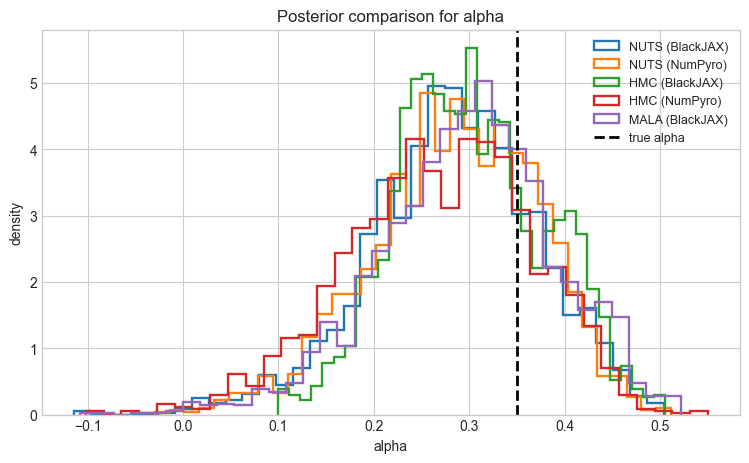

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for r in results:
    ax.hist(
        r["alpha_samples"],
        bins=35,
        density=True,
        histtype="step",
        linewidth=1.7,
        label=r["name"],
    )

ax.axvline(float(true_params["alpha"]), color="black", linestyle="--", linewidth=2, label="true alpha")
ax.set_title("Posterior comparison for alpha")
ax.set_xlabel("alpha")
ax.set_ylabel("density")
ax.legend(loc="best", fontsize=9)
plt.show()